In [1]:
import warnings
import numpy as np

# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The purpose of the exercise is to implement a recommendation system for a movie search engine.

When we think about selecting a video that our user will like, let's first consider what data we have available? First of all, we have information in the database about how our user rated the movies he once watched. It's worth noting here that this is absolutely not all of the movies in our database given, and most often it's a heavily limited subset of a huge set of movies. So we can find out which movies our user liked and which ones he didn't. 

Is this all the data available? Well, no! We also have information about the preferences of other users! So we can find in the data a sample of users who have similar movie taste to our user. Note that virtually every such other user has watched some movies that our user has never watched before! The idea behind collaborative filtering is very simple: if another user with similar tastes rated a movie highly, our user will probably rate it highly too! Let's recommend movies that users with similar tastes have rated highly!


Let's formalize some ideas:
 - how to count the similarity between users' tastes? 
 
 Just calculate the correlation between their movie ratings. Users with a strongly positive correlation have similar tastes, and those with a strongly negative correlation have opposite tastes;) 
 
 - Having found similar users, how to count the predicted rating of the video by our user?
 
 We count the weighted average of ratings of users with similar tastes where the weight is the measure of similarity (correlation). The closer a user's tastes are to us, the more weight his rating has for us. (slide 27, http://www.mmds.org/mmds/v2.1/ch09-recsys1.pdf)


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

df = pd.read_csv('./ratings.csv')
df

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


### Task
Modify the dataframe to have moveID as index, userID as column and rating as values

In [3]:
ratings_matrix = df.pivot(index='movieId', columns='userId', values='rating')
ratings_matrix

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Task
Let's try to recommend movies for user 610. Calculate the correlation between this user and the remaining ones.

In [4]:
user = 610

In [5]:
target = ratings_matrix[user]
similarities = ratings_matrix.corrwith(target)
similarities = similarities.drop(user)
similarities_sorted = similarities.sort_values(ascending=False)
similarities_sorted

userId
576    1.000000
442    1.000000
545    1.000000
158    0.911322
92     0.903696
         ...   
406         NaN
429         NaN
431         NaN
508         NaN
575         NaN
Length: 609, dtype: float64

### Task
There are a few users with the perfect match. Isn't it suspicious? Check it

In [6]:
perfect_matches = similarities_sorted[similarities_sorted > 0.999999]
perfect_matches

userId
576    1.0
442    1.0
545    1.0
dtype: float64

In [7]:
for user_id in perfect_matches.index:
    # Count non-NaN values in both target and similar user
    overlap = ratings_matrix.loc[:, [user, user_id]].dropna().shape[0]
    print(f"User {user_id}: {overlap} overlapping movies")

User 576: 2 overlapping movies
User 442: 2 overlapping movies
User 545: 2 overlapping movies


### Task
Find 5 users with at least 5 common movies with user=610 and the highest correlation with that user

In [8]:
target_user = 610
target = ratings_matrix[target_user]
similarities = ratings_matrix.corrwith(target)
overlap_counts = ratings_matrix.apply(lambda col: col.notna() & target.notna()).sum()
valid_users = overlap_counts[overlap_counts >= 5].index.difference([target_user])
similarities_filtered = similarities.loc[valid_users]
top_5_users = similarities_filtered.sort_values(ascending=False).head(5)
top_5_users

userId
92     0.903696
120    0.879537
463    0.823180
138    0.822192
494    0.811761
dtype: float64

### Task
Predict scores for each movie based on the most correlated users. Use weighted average with correlation coefficient as weights.
$$\hat{y_j} = \frac{\sum_{i \in U} w_iy_{ij}}{\sum_{i \in U} w_i}$$

$U$ is a set of those users that also watched $j$th moveie, $w$ denotes the correlation between our user and $i$th user, $y_{ij}$ is a score given by $i$th user to $j$th movie
Use only movies watched by at least two users from the considered set

In [9]:
# Weighted prediction function
def weighted_prediction_all(row):
    rated_users = row.dropna()
    if len(rated_users) < 2:  # skip if fewer than 2 ratings
        return np.nan
    weights = similarities[rated_users.index]  # correlation as weights
    return np.dot(rated_users, weights) / weights.sum()

In [10]:
target_user = 610
target_ratings = ratings_matrix[target_user]
similarities = ratings_matrix.corrwith(target_ratings)
similarities = similarities.drop(target_user)
other_users_ratings = ratings_matrix.drop(columns=target_user)
valid_movies_mask = (other_users_ratings.notna().sum(axis=1) >= 2)
valid_movies = other_users_ratings[valid_movies_mask]

In [11]:
predicted_scores = valid_movies.apply(weighted_prediction_all, axis=1)
predicted_scores_sorted = predicted_scores.sort_values(ascending=False)
predicted_scores_sorted

movieId
171      37.830867
78637    31.691521
3719     26.983291
60333    25.930566
2961     23.428869
           ...    
46972          NaN
47382          NaN
54272          NaN
56949          NaN
58107          NaN
Length: 6185, dtype: float64

### Task
How to check the quality of our recommendations? 

We have to remove a few scores from the dataset and then compare predictions with the real ones.

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate_recommendations(ratings_matrix, user_id, n_hidden=5, random_state=42, plot=True):
    np.random.seed(random_state)
    target_ratings = ratings_matrix[user_id].copy()
    
    rated_movies = target_ratings.dropna().index
    if len(rated_movies) < n_hidden:
        n_hidden = len(rated_movies)
    hidden_movies = np.random.choice(rated_movies, size=n_hidden, replace=False)
    hidden_ratings = target_ratings[hidden_movies].copy()
    ratings_matrix.loc[hidden_movies, user_id] = np.nan

    target = ratings_matrix[user_id]
    similarities = ratings_matrix.corrwith(target).drop(user_id)

    predicted_scores = {}
    for movie in ratings_matrix.index:
        users_who_rated = ratings_matrix.loc[movie].dropna().index
        relevant_users = users_who_rated.intersection(similarities.index)
        if len(relevant_users) < 2:
            continue

        weights = similarities[relevant_users]
        ratings = ratings_matrix.loc[movie, relevant_users].copy()

        negative_mask = weights < 0
        ratings[negative_mask] = 6 - ratings[negative_mask]
        weights = weights.abs()

        denom = np.sum(weights)
        if denom == 0:
            continue

        pred = np.sum(weights * ratings) / denom
        predicted_scores[movie] = np.clip(pred, 0, 5)

    predicted_scores = pd.Series(predicted_scores)
    hidden_predicted = [m for m in hidden_movies if m in predicted_scores.index]
    if not hidden_predicted:
        if plot:
            print("No hidden movies could be predicted with the current data.")
        ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
        return None, None

    predicted_hidden = predicted_scores[hidden_predicted]
    actual_hidden = hidden_ratings[hidden_predicted]

    mae = mean_absolute_error(actual_hidden, predicted_hidden)
    rmse = np.sqrt(mean_squared_error(actual_hidden, predicted_hidden))

    if plot:
        print(f"Hidden Movies (predicted): {list(hidden_predicted)}")
        print(f"Actual Ratings: {list(actual_hidden)}")
        print(f"Predicted Ratings: {list(predicted_hidden)}")
        print(f"\nMean Absolute Error (MAE): {mae:.3f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

        plt.figure(figsize=(6, 6))
        plt.scatter(actual_hidden, predicted_hidden, color='blue', label='Predicted vs Actual')
        plt.plot([0, 5], [0, 5], 'r--', label='Perfect Prediction (y=x)')
        plt.xlabel("Actual Ratings")
        plt.ylabel("Predicted Ratings")
        plt.title(f"User {user_id} - Predicted vs Actual Ratings")
        plt.xlim(0, 5)
        plt.ylim(0, 5)
        plt.grid(True)
        plt.legend()
        plt.show()

    ratings_matrix.loc[hidden_movies, user_id] = target_ratings[hidden_movies]
    return mae, rmse

Hidden Movies (predicted): [np.int64(53996), np.int64(4725), np.int64(1573), np.int64(63082), np.int64(53953), np.int64(110102), np.int64(1273), np.int64(160080), np.int64(76077), np.int64(52722), np.int64(3745), np.int64(112852), np.int64(8983), np.int64(3328)]
Actual Ratings: [3.0, 4.0, 3.5, 5.0, 4.0, 4.5, 5.0, 3.0, 3.5, 3.5, 3.0, 4.5, 3.5, 5.0]
Predicted Ratings: [3.1790423865915796, 3.725404804076884, 3.2946276945291264, 3.7891422179843497, 3.165677451676979, 3.659548403822181, 3.79948144778198, 2.859679805939634, 3.0146858946585144, 2.8569595617164625, 3.1995836865074345, 3.762463609501714, 3.4433469276743516, 3.6362898994899355]

Mean Absolute Error (MAE): 0.598
Root Mean Squared Error (RMSE): 0.736


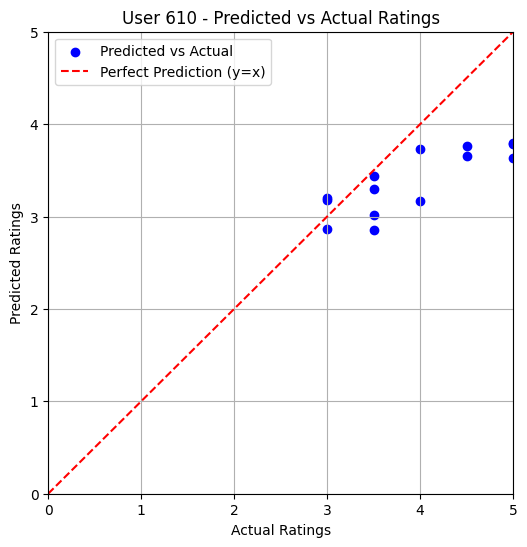

(0.5979513110176359, np.float64(0.7355726521055906))

In [13]:
evaluate_recommendations(ratings_matrix, user_id=610, n_hidden=20)

Try to improve the system, you can use the following ideas:
 - Can we use more users (e.g. with negative correlation)?
 - Which difference is more important predicting 5 when a real score is 4 or predicting 3 instead of 2?
 - Did we use the best value for the minimal number of common movies?
 - Is prediction for a movie seen by just one user trustworthy?
 
 
Describe your approach, its strengths and weaknesses, and analyze the results. Send the report (notebook with comments/markdown) within 144 hours after the class to gmiebs@cs.put.poznan.pl, start the subject with [IR]

Credits to F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872 and Mateusz Lango